<a href="https://colab.research.google.com/github/Olacherish/DataScienceClass/blob/main/REAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Capstone Project: Transfer Learning with PyTorch
### CNN Transfer Learning (Image Classification)


### Task 1: Prepare data and apply augmentations

This section handles the dataset loading and preprocessing steps. We will define transformations for both training and validation sets. Training transformations will include data augmentation techniques like random resizing and flipping, while validation transformations will only resize and normalize the images.


In [ ]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import copy
from tqdm.notebook import tqdm

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# Define data transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224), # Randomly crop and resize to 224x224
        transforms.RandomHorizontalFlip(), # Randomly flip the image horizontally
        transforms.ToTensor(), # Convert PIL Image or numpy.ndarray to tensor
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Normalize with ImageNet mean and std
    ]),
    'val': transforms.Compose([
        transforms.Resize(256), # Resize the image to 256x256
        transforms.CenterCrop(224), # Crop the center to 224x224
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

print("Data transformations defined.")

Data transformations defined.


In [ ]:
# Load the Oxford-IIIT Pet dataset
# The dataset will be downloaded to a 'data' directory in the current working directory

# NOTE: For the first run, set download=True. After the dataset is downloaded,
# you can set download=False to avoid re-downloading.

try:
    image_datasets = {
        'train': datasets.OxfordIIITPet(root='./data', split='trainval', transform=data_transforms['train'], download=True),
        'val': datasets.OxfordIIITPet(root='./data', split='test', transform=data_transforms['val'], download=True)
    }
    print("Oxford-IIIT Pet dataset loaded successfully.")
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please ensure you have an active internet connection for download, or the dataset is present if download=False.")
    raise

# Create data loaders
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=2)
    for x in ['train', 'val']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f"Number of training images: {dataset_sizes['train']}")
print(f"Number of validation images: {dataset_sizes['val']}")
print(f"Number of classes: {len(class_names)}")
print(f"Class names: {class_names[:5]}...") # Print first 5 class names
print(f"Using device: {device}")

100%|██████████| 792M/792M [00:23<00:00, 33.5MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.9MB/s]


Oxford-IIIT Pet dataset loaded successfully.
Number of training images: 3680
Number of validation images: 3669
Number of classes: 37
Class names: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle']...
Using device: cpu


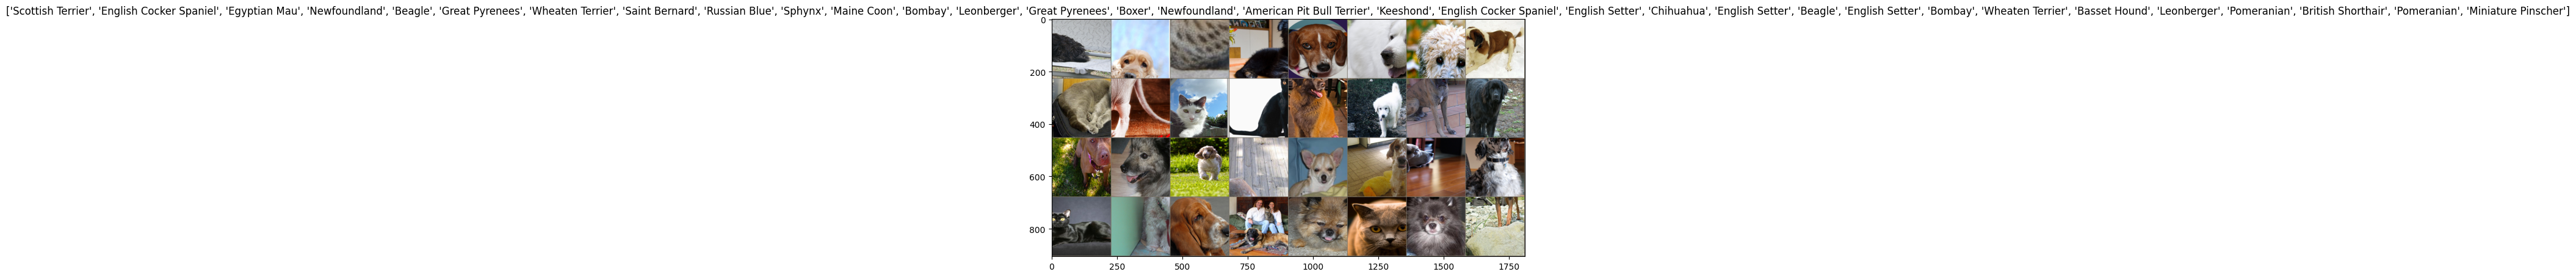

Sample images displayed.


In [ ]:
# Helper function to visualize a few training images
import torchvision # Added this import statement

def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

fig = plt.figure(figsize=(10, 10))
imshow(out, title=[class_names[x] for x in classes])
plt.show()
print("Sample images displayed.")

### Task 2: Load pretrained CNN and replace classifier head

In this step, we will load a pre-trained Convolutional Neural Network (CNN) model from `torchvision.models`. We'll use ResNet18 for this project. After loading, we will modify its final classification layer to match the number of classes in our Oxford-IIIT Pet dataset (37 classes).

In [ ]:
from torchvision import models
import torch.nn as nn

# Load a pretrained ResNet50 model
model_ft = models.resnet50(weights='IMAGENET1K_V1')

# Freeze all parameters first
for param in model_ft.parameters():
    param.requires_grad = False

# Get the number of input features for the last fully connected layer
num_ftrs = model_ft.fc.in_features

# Replace the classifier head with a new one for our number of classes
# The parameters of this new layer will have requires_grad=True by default
model_ft.fc = nn.Linear(num_ftrs, len(class_names))

# Move the model to the appropriate device (CPU or GPU)
model_ft = model_ft.to(device);

print("Pretrained ResNet50 model loaded and classifier head replaced.")
print(f"New output layer: {model_ft.fc}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 176MB/s]


NameError: name 'class_names' is not defined

### Task 3: Train with frozen layers, then fine-tune

This task involves two main training phases:
1.  **Training with frozen layers**: Initially, we will freeze all parameters of the pre-trained model and only train the newly added classifier head. This helps in quickly adapting the model to our specific dataset without destroying the learned features.
2.  **Fine-tuning**: After the initial training, we will unfreeze some or all layers of the pre-trained model and continue training with a lower learning rate. This allows the model to adjust the pre-trained weights to better suit the specific characteristics of our pet image dataset.

In [ ]:
def train_model(model, dataloaders, dataset_sizes, criterion, optimizer, num_epochs=25, is_inception=False):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in tqdm(dataloaders[phase], desc=f'{phase} phase'):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    if is_inception and phase == 'train':
                        # From https://pytorch.org/tutorials/beginner/finetuning_torchvision_models_tutorial.html
                        outputs, aux_outputs = model(inputs)
                        loss1 = criterion(outputs, labels)
                        loss2 = criterion(aux_outputs, labels)
                        loss = loss1 + 0.4*loss2
                    else:
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

            # Store history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

print("Training function defined.")

Training function defined.


#### Phase 1: Training with frozen layers

In this phase, we freeze all the parameters in the network except for the final fully connected layer. This means that the gradients will only be computed for the parameters of the new `model_ft.fc` layer, and the weights of the pre-trained convolutional layers will remain unchanged. This approach helps in faster convergence and prevents overfitting, especially with smaller datasets, by leveraging the powerful feature extraction capabilities of the pre-trained network.

In [ ]:
import torch.optim as optim

optimizer_ft_frozen = optim.Adam(model_ft.fc.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print("Model layers frozen and optimizer for frozen training set up.")

# Train the model with frozen layers
model_frozen, history_frozen = train_model(model_ft, dataloaders, dataset_sizes, criterion, optimizer_ft_frozen, num_epochs=20)

print("Training with frozen layers complete.")

Model layers frozen and optimizer for frozen training set up.


NameError: name 'train_model' is not defined

#### Phase 2: Fine-tuning the entire model

After training the classifier head, we will fine-tune the entire network. This involves unfreezing some or all of the pre-trained layers and training them with a much smaller learning rate. This allows the model to slightly adjust the weights of the convolutional base to be more specific to our pet dataset, potentially leading to higher accuracy. We will use the model weights learned from the frozen layer training as a starting point.

In [ ]:
# Unfreeze all layers for fine-tuning
for param in model_frozen.parameters():
    param.requires_grad = True

# Observe that all parameters are now being optimized
# We use a much smaller learning rate for fine-tuning
optimizer_ft_finetune = optim.Adam(model_frozen.parameters(), lr=0.0001)

print("Model layers unfrozen and optimizer for fine-tuning set up.")

# Train the model with fine-tuning
model_finetuned, history_finetuned = train_model(model_frozen, dataloaders, dataset_sizes, criterion, optimizer_ft_finetune, num_epochs=20)

print("Fine-tuning complete.")

NameError: name 'model_frozen' is not defined

### Task 4: Evaluate with accuracy

In this section, we will evaluate the performance of both the model trained with frozen layers and the fine-tuned model on the validation set. We will report the final accuracy and also visualize the training and validation loss and accuracy over epochs for both training stages.

In [ ]:
# Function to plot training history
def plot_history(history, title):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Val Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

print("Plotting function defined.")

Plotting function defined.


### Verify Environment Initialization

Let's check if the crucial objects and functions are correctly initialized from the preceding cells. This will help confirm if the `NameError`s are due to cells not being run in order.

In [ ]:
import torch
print('--- Verifying Model and Function Objects ---')

# Check for model_ft
if 'model_ft' in locals() and isinstance(model_ft, torch.nn.Module):
    print(f"'model_ft' is defined and is a torch.nn.Module (Type: {type(model_ft)})\nOutput layer: {model_ft.fc}")
else:
    print("'model_ft' is not defined or is not a torch.nn.Module. Please ensure Task 2 cells are run.")

# Check for train_model function
if 'train_model' in locals() and callable(train_model):
    print(f"'train_model' function is defined (Type: {type(train_model)})")
else:
    print("'train_model' function is not defined. Please ensure the training function cell in Task 3 is run.")

# Check for class_names
if 'class_names' in locals() and isinstance(class_names, list):
    print(f"'class_names' is defined and is a list (Length: {len(class_names)}, First 5: {class_names[:5]})")
else:
    print("'class_names' is not defined or is not a list. Please ensure Task 1 data loading cells are run.")

# Check for dataloaders
if 'dataloaders' in locals() and isinstance(dataloaders, dict) and 'train' in dataloaders and 'val' in dataloaders:
    print(f"'dataloaders' is defined and contains 'train' and 'val' (Train size: {len(dataloaders['train'].dataset)}, Val size: {len(dataloaders['val'].dataset)})")
else:
    print("'dataloaders' is not defined or incomplete. Please ensure Task 1 data loading cells are run.")

print('\n--- Verification Complete ---')
print('\nIf any of the above checks failed, please run all cells from the beginning of the notebook (Runtime -> Run all) to ensure all variables and functions are correctly initialized.')

--- Verifying Model and Function Objects ---
'model_ft' is defined and is a torch.nn.Module (Type: <class 'torchvision.models.resnet.ResNet'>)
Output layer: Linear(in_features=2048, out_features=1000, bias=True)
'train_model' function is not defined. Please ensure the training function cell in Task 3 is run.
'class_names' is not defined or is not a list. Please ensure Task 1 data loading cells are run.
'dataloaders' is not defined or incomplete. Please ensure Task 1 data loading cells are run.

--- Verification Complete ---

If any of the above checks failed, please run all cells from the beginning of the notebook (Runtime -> Run all) to ensure all variables and functions are correctly initialized.


#### Evaluation of Model after Frozen Layers Training

In [ ]:
# Evaluate the model after frozen layers training
model = model_frozen # Use the model trained with frozen layers
model.eval() # Set model to evaluate mode
running_corrects = 0

for inputs, labels in tqdm(dataloaders['val'], desc='Evaluating Frozen Model'):
    inputs = inputs.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

    running_corrects += torch.sum(preds == labels.data)

accuracy_frozen = running_corrects.double() / dataset_sizes['val']
print(f'Validation Accuracy after Frozen Layers Training: {accuracy_frozen:.4f}')

plot_history(history_frozen, 'Frozen Layers Training')


NameError: name 'model_frozen' is not defined

#### Evaluation of Model after Fine-tuning

---



In [ ]:
# Evaluate the model after fine-tuning
model = model_finetuned # Use the fine-tuned model
model_finetuned.eval() # Set model to evaluate mode
running_corrects = 0

for inputs, labels in tqdm(dataloaders['val'], desc='Evaluating Fine-tuned Model'):
    inputs = inputs.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        outputs = model_finetuned(inputs)
        _, preds = torch.max(outputs, 1)

    running_corrects += torch.sum(preds == labels.data)

accuracy_finetuned = running_corrects.double() / dataset_sizes['val']
print(f'Validation Accuracy after Fine-tuning: {accuracy_finetuned:.4f}')

plot_history(history_finetuned, 'Fine-tuning Training')

NameError: name 'model_finetuned' is not defined

### Comparison of Results

Let's compare the accuracy achieved after training with frozen layers versus after fine-tuning.

In [ ]:
print(f"Accuracy with Frozen Layers: {accuracy_frozen:.4f}")
print(f"Accuracy after Fine-tuning: {accuracy_finetuned:.4f}")

if accuracy_finetuned > accuracy_frozen:
    print("Fine-tuning improved the model's accuracy.")
elif accuracy_finetuned < accuracy_frozen:
    print("Fine-tuning slightly decreased or did not improve the model's accuracy. This can happen if the learning rate was too high or the fine-tuning was too long, leading to overfitting or degradation of pre-trained features.")
else:
    print("Fine-tuning resulted in similar accuracy.")


NameError: name 'accuracy_frozen' is not defined

# Welcome to Colab!

## Google Colab is available in VS Code!
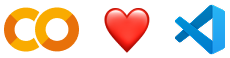

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

## Access popular AI models via Google-Colab-AI Without an API Key
All users have access to most popular LLMs via the `google-colab-ai` Python library, and paid users have access to a wider selection of models. For more details, refer to the [getting started with google colab ai](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb).



In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

## Explore the Gemini API
The Gemini API gives you access to Gemini models created by Google DeepMind. Gemini models are built from the ground up to be multimodal, so you can reason seamlessly across text, images, code, and audio.

**How to get started?**
*  Go to [Google AI Studio](https://aistudio.google.com/) and log in with your Google account.
*  [Create an API key](https://aistudio.google.com/app/apikey).
* Use a quickstart for [Python](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb), or call the REST API using [curl](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb).

**Discover Gemini's advanced capabilities**
*  Play with Gemini [multimodal outputs](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb), mixing text and images in an iterative way.
*  Discover the [multimodal Live API](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb ) (demo [here](https://aistudio.google.com/live)).
*  Learn how to [analyze images and detect items in your pictures](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb") using Gemini (bonus, there's a [3D version](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb) as well!).
*  Unlock the power of [Gemini thinking model](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb), capable of solving complex task with its inner thoughts.
      
**Explore complex use cases**
*  Use [Gemini grounding capabilities](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb) to create a report on a company based on what the model can find on internet.
*  Extract [invoices and form data from PDF](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb) in a structured way.
*  Create [illustrations based on a whole book](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb) using Gemini large context window and Imagen.

To learn more, check out the [Gemini cookbook](https://github.com/google-gemini/cookbook) or visit the [Gemini API documentation](https://ai.google.dev/docs/).


Colab now has AI features powered by [Gemini](https://gemini.google.com). The video below provides information on how to use these features, whether you're new to Python, or a seasoned veteran.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  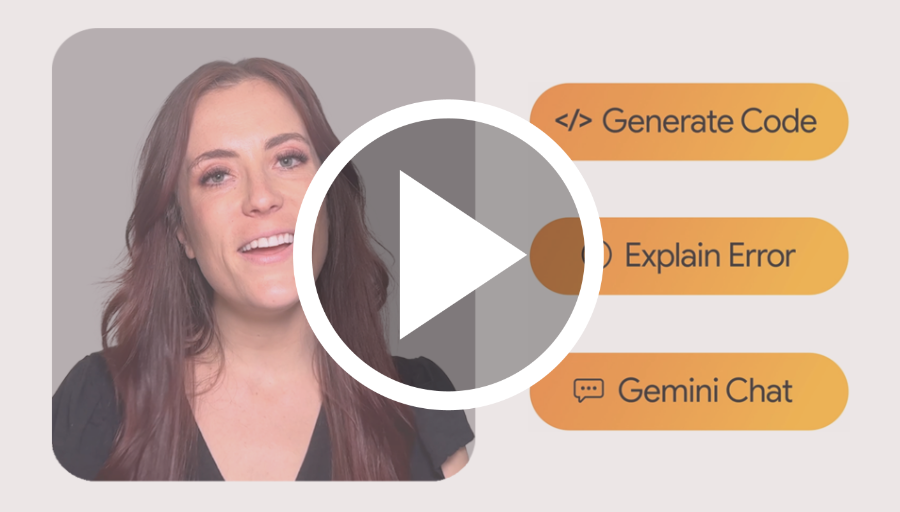
  </a>
</center>

<div class="markdown-google-sans">
  <h2>What is Colab?</h2>
</div>

Colab, or "Colaboratory", allows you to write and execute Python in your browser, with
- Zero configuration required
- Access to GPUs free of charge
- Easy sharing

Whether you're a **student**, a **data scientist** or an **AI researcher**, Colab can make your work easier. Watch [Introduction to Colab](https://www.youtube.com/watch?v=inN8seMm7UI) or [Colab Features You May Have Missed](https://www.youtube.com/watch?v=rNgswRZ2C1Y) to learn more, or just get started below!

<div class="markdown-google-sans">

## **Getting started**
</div>

The document you are reading is not a static web page, but an interactive environment called a **Colab notebook** that lets you write and execute code.

For example, here is a **code cell** with a short Python script that computes a value, stores it in a variable, and prints the result:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut "Command/Ctrl+Enter". To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Colab notebooks allow you to combine **executable code** and **rich text** in a single document, along with **images**, **HTML**, **LaTeX** and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To learn more, see [Overview of Colab](/notebooks/basic_features_overview.ipynb). To create a new Colab notebook you can use the File menu above, or use the following link: [create a new Colab notebook](http://colab.research.google.com#create=true).

Colab notebooks are Jupyter notebooks that are hosted by Colab. To learn more about the Jupyter project, see [jupyter.org](https://www.jupyter.org).

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyze and visualize data. The code cell below uses **numpy** to generate some random data, and uses **matplotlib** to visualize it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

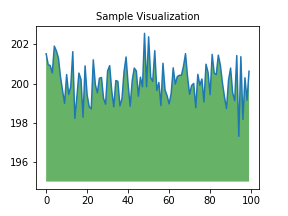

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer (ViT) for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Train a miniGPT language model with JAX AI Stack](https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html)
- [LoRA/QLoRA finetuning for LLM using Tunix](https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb)
- [Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA](https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/)
- [Loading Hugging Face Transformers Checkpoints](https://keras.io/keras_hub/guides/hugging_face_keras_integration/)
- [8-bit Integer Quantization in Keras](https://keras.io/guides/int8_quantization_in_keras/)
- [Float8 training and inference with a simple Transformer model](https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/)
- [Pretraining a Transformer from scratch with KerasHub](https://keras.io/keras_hub/guides/transformer_pretraining/)
- [Simple MNIST convnet](https://keras.io/examples/vision/mnist_convnet/)
- [Image classification from scratch using Keras 3](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Image Classification with KerasHub](https://keras.io/keras_hub/guides/classification_with_keras_hub/)
